# ECG Signal Preprocessing & Physiological Validation Pipeline
## MIT-BIH Arrhythmia Database

**Purpose:** Build a physiologically correct ECG preprocessing pipeline that prepares the signal  
for future peak detection — *without* performing any peak detection, classification, or machine learning.

**Pipeline stages:**
1. Load data from MIT-BIH using WFDB
2. Extract user-selectable segment
3. Baseline wander removal
4. Powerline interference notch filtering (50/60 Hz)
5. Bandpass filtering (preserving P-QRS-T morphology)
6. Optional amplitude normalization (visualization only)
7. Physiological plausibility verification
8. Annotation-based heart rate & RR interval analysis

## Cell 1 — Install Dependencies

In [1]:
# Install the WFDB (WaveForm DataBase) package — the official Python interface
# for PhysioNet databases, including the MIT-BIH Arrhythmia Database.
# Also ensure scipy is available for signal processing filters.
!pip install wfdb scipy numpy matplotlib --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Imports

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Standard scientific stack
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

# ─────────────────────────────────────────────────────────────────────────────
# WFDB — reads MIT-BIH .dat (signal) and .atr (annotation) files directly
# from PhysioNet or from a local download.
# ─────────────────────────────────────────────────────────────────────────────
import wfdb

# ─────────────────────────────────────────────────────────────────────────────
# SciPy signal processing — used for all filtering operations.
# We use second-order sections (sos) throughout because they are numerically
# stable for high-order IIR filters at low cut-off frequencies relative to fs.
# ─────────────────────────────────────────────────────────────────────────────
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, medfilt

warnings.filterwarnings('ignore')  # Suppress minor deprecation notices

# ─────────────────────────────────────────────────────────────────────────────
# Matplotlib style — publication quality
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'grid.alpha': 0.4,
    'lines.linewidth': 0.9,
    'font.family': 'DejaVu Sans',
})

print("All imports successful.")

All imports successful.


## Cell 3 — User Configuration

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# ★  USER-CONFIGURABLE PARAMETERS  ★
# Modify these values to explore different records and durations.
# ─────────────────────────────────────────────────────────────────────────────

RECORD_NAME      = '100'    # MIT-BIH record ID (100–234); '100' is the canonical normal sinus rhythm example
CHANNEL          = 0        # Lead to analyse: 0 = MLII (most informative), 1 = V5
SEGMENT_DURATION = 10       # Duration in seconds to extract (5, 10, or 20 recommended)
SEGMENT_START_S  = 0        # Start time in seconds (0 = beginning of record)
POWERLINE_FREQ   = 60       # Set to 50 for European/Asian equipment, 60 for North American
NORMALIZE_FINAL  = True     # Z-score normalize final signal FOR VISUALIZATION ONLY

# MIT-BIH records available on PhysioNet:
# Normal sinus rhythm:  100, 101, 103
# Arrhythmia examples:  108 (ST changes), 119 (VT), 200 (frequent PVCs)
# ─────────────────────────────────────────────────────────────────────────────

print(f"Configuration:")
print(f"  Record          : {RECORD_NAME}")
print(f"  Channel (Lead)  : {CHANNEL}")
print(f"  Segment duration: {SEGMENT_DURATION} s")
print(f"  Start offset    : {SEGMENT_START_S} s")
print(f"  Powerline freq  : {POWERLINE_FREQ} Hz")
print(f"  Normalize output: {NORMALIZE_FINAL}")

Configuration:
  Record          : 100
  Channel (Lead)  : 0
  Segment duration: 10 s
  Start offset    : 0 s
  Powerline freq  : 60 Hz
  Normalize output: True


## Cell 4 — Load Signal & Annotations from MIT-BIH

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# REAL-TIME ECG ACQUISITION FROM SERIAL PORT
# Replaces MIT-BIH loading section
# ─────────────────────────────────────────────────────────────────────────────

import serial
import numpy as np

# ----------------------------
# Serial Configuration
# ----------------------------

PORT = "COM6"          # Change if needed
BAUDRATE = 115200

# ----------------------------
# ECG Acquisition Parameters
# ----------------------------

FS = 360               # Replace with actual sensor sampling rate
WINDOW_SECONDS = 5

WINDOW_SIZE = FS * WINDOW_SECONDS

print("Connecting to ECG device...")

ser = serial.Serial(PORT, BAUDRATE, timeout=1)

print("Connected Successfully")
print(f"Sampling Rate : {FS} Hz")
print(f"Window Length : {WINDOW_SECONDS} sec")
print(f"Samples Needed: {WINDOW_SIZE}")

# ----------------------------
# Collect ECG Samples
# ----------------------------

buffer = []

print("\nCollecting ECG data...")

while len(buffer) < WINDOW_SIZE:

    try:
        line = ser.readline().decode().strip()

        if line == "":
            continue

        sample = float(line)

        buffer.append(sample)

    except Exception:
        continue

ser.close()

# ----------------------------
# Convert to NumPy Array
# ----------------------------

SIGNAL_FULL = np.array(buffer)

TOTAL_SAMPLES = len(SIGNAL_FULL)
TOTAL_DURATION_S = TOTAL_SAMPLES / FS

print("\nAcquisition Complete")
print(f"Total Samples : {TOTAL_SAMPLES}")
print(f"Duration      : {TOTAL_DURATION_S:.2f} sec")

# Dummy placeholders so later code doesn't break
LEAD_NAME = "Real-Time ECG"
ANNOTATED_BEATS = "Not Available"

print(f"Lead           : {LEAD_NAME}")
print(f"Annotations    : {ANNOTATED_BEATS}")

Connecting to ECG device...


SerialException: could not open port 'COM6': FileNotFoundError(2, 'The system cannot find the file specified.', None, 2)

In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # WHY MIT-BIH?
# #   The MIT-BIH Arrhythmia Database (Moody & Mark, 2001) contains 48 half-hour
# #   recordings sampled at 360 Hz with 11-bit resolution over a ±5 mV range.
# #   It is the gold-standard benchmark for ECG algorithm evaluation.
# #
# # WFDB rdrecord() downloads .hea (header) + .dat (ADC samples) from PhysioNet
# # and decodes them into physical units (mV) using the stored gain/baseline.
# # ─────────────────────────────────────────────────────────────────────────────

# print(f"Downloading record {RECORD_NAME} from PhysioNet MIT-BIH database...")

# record = wfdb.rdrecord(
#     RECORD_NAME,
#     pn_dir='mitdb',          # PhysioNet database identifier
#     channels=[CHANNEL],      # Only load the requested lead to save memory
# )

# # ─────────────────────────────────────────────────────────────────────────────
# # Load beat annotations (.atr file).
# # The annotation file stores the SAMPLE INDEX of each annotated beat alongside
# # a beat-type symbol (N = normal, V = PVC, A = atrial premature, etc.).
# # We use these as ground truth — NO custom peak detection is performed.
# # ─────────────────────────────────────────────────────────────────────────────
# annotation = wfdb.rdann(
#     RECORD_NAME,
#     'atr',                   # Annotation type: 'atr' = beat annotations
#     pn_dir='mitdb',
# )

# # ─────────────────────────────────────────────────────────────────────────────
# # Extract metadata
# # ─────────────────────────────────────────────────────────────────────────────
# FS               = record.fs                    # Sampling frequency (Hz), typically 360 for MIT-BIH
# SIGNAL_FULL      = record.p_signal[:, 0]        # Full signal in mV (physical units after ADC decoding)
# LEAD_NAME        = record.sig_name[0]           # e.g. 'MLII' or 'V5'
# TOTAL_SAMPLES    = len(SIGNAL_FULL)
# TOTAL_DURATION_S = TOTAL_SAMPLES / FS

# print(f"\nRecord loaded successfully.")
# print(f"  Lead            : {LEAD_NAME}")
# print(f"  Sampling rate   : {FS} Hz")
# print(f"  Total samples   : {TOTAL_SAMPLES:,}")
# print(f"  Total duration  : {TOTAL_DURATION_S:.1f} s ({TOTAL_DURATION_S/60:.2f} min)")
# print(f"  ADC units       : {record.units[0]}")
# print(f"  Total annotated beats: {len(annotation.sample):,}")


Record loaded successfully.
  Lead            : MLII
  Sampling rate   : 360 Hz
  Total samples   : 650,000
  Total duration  : 1805.6 s (30.09 min)
  ADC units       : mV
  Total annotated beats: 2,274


## Cell 5 — Extract Segment

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Convert user-specified time boundaries to sample indices.
# Validate that the requested segment fits within the recording.
# ─────────────────────────────────────────────────────────────────────────────

start_sample = int(SEGMENT_START_S * FS)
end_sample   = int((SEGMENT_START_S + SEGMENT_DURATION) * FS)

# Guard against out-of-bounds requests
if end_sample > TOTAL_SAMPLES:
    end_sample = TOTAL_SAMPLES
    print(f"⚠ Requested end exceeds record length. Clamped to {TOTAL_SAMPLES} samples.")

# ─────────────────────────────────────────────────────────────────────────────
# Extract signal segment (mV values)
# ─────────────────────────────────────────────────────────────────────────────
ecg_raw = SIGNAL_FULL[start_sample:end_sample].copy()

# ─────────────────────────────────────────────────────────────────────────────
# Build time axis in seconds (for plotting x-axis)
# ─────────────────────────────────────────────────────────────────────────────
N_samples = len(ecg_raw)
time_axis = np.arange(N_samples) / FS   # seconds

# ─────────────────────────────────────────────────────────────────────────────
# Extract annotations that fall WITHIN this segment
# Annotation sample indices are absolute; subtract start_sample to get
# relative indices within our extracted segment.
# ─────────────────────────────────────────────────────────────────────────────
mask          = (annotation.sample >= start_sample) & (annotation.sample < end_sample)
ann_samples   = annotation.sample[mask] - start_sample   # Relative sample indices
ann_symbols   = np.array(annotation.symbol)[mask]        # Beat type symbols

print(f"Segment extracted:")
print(f"  Samples        : {N_samples:,}")
print(f"  Duration       : {N_samples/FS:.3f} s")
print(f"  Start time     : {SEGMENT_START_S} s  (sample {start_sample:,})")
print(f"  End time       : {SEGMENT_START_S + SEGMENT_DURATION} s  (sample {end_sample:,})")
print(f"  Annotated beats in segment: {len(ann_samples)}")
print(f"  Beat types     : {dict(zip(*np.unique(ann_symbols, return_counts=True)))}")

Segment extracted:
  Samples        : 3,600
  Duration       : 10.000 s
  Start time     : 0 s  (sample 0)
  End time       : 10 s  (sample 3,600)
  Annotated beats in segment: 14
  Beat types     : {np.str_('+'): np.int64(1), np.str_('A'): np.int64(1), np.str_('N'): np.int64(12)}


## Cell 6 — Physiological Validation of Raw Signal

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute signal quality and physiological plausibility metrics on the RAW
# signal before any filtering.  These are reference values to compare against
# after filtering to confirm we have not distorted the signal.
# ─────────────────────────────────────────────────────────────────────────────

def compute_signal_metrics(signal, fs, label='Signal'):
    """
    Compute and return a dictionary of signal-level and physiological metrics.
    Also prints a formatted summary with warnings for out-of-range values.
    """
    metrics = {}
    metrics['n_samples']   = len(signal)
    metrics['duration_s']  = len(signal) / fs
    metrics['fs_hz']       = fs
    metrics['mean_mV']     = np.mean(signal)
    metrics['std_mV']      = np.std(signal)
    metrics['min_mV']      = np.min(signal)
    metrics['max_mV']      = np.max(signal)
    metrics['p2p_mV']      = np.ptp(signal)                         # Peak-to-peak amplitude
    metrics['power']       = np.mean(signal ** 2)                   # Signal power (mean square)
    metrics['rms_mV']      = np.sqrt(metrics['power'])               # RMS amplitude

    # ─── SNR estimate ──────────────────────────────────────────────────────
    # True SNR requires a noise reference.  We approximate noise by
    # computing the high-frequency content above 40 Hz (above ECG band).
    # Signal power is estimated in the 0.5–40 Hz band via a simple bandpass.
    # This is an engineering approximation; a calibrated noise floor would
    # require a dedicated noise measurement interval.
    from scipy.signal import butter, sosfiltfilt
    sos_sig   = butter(4, [0.5, 40.0], btype='bandpass', fs=fs, output='sos')
    sos_noise = butter(4, 40.0, btype='high', fs=fs, output='sos')
    sig_band  = sosfiltfilt(sos_sig,   signal)
    noise_band= sosfiltfilt(sos_noise, signal)
    sig_pwr   = np.mean(sig_band   ** 2)
    noise_pwr = np.mean(noise_band ** 2)
    if noise_pwr > 0:
        metrics['snr_dB'] = 10 * np.log10(sig_pwr / noise_pwr)
    else:
        metrics['snr_dB'] = np.inf

    # ─── Print formatted report ─────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  Signal Metrics — {label}")
    print(f"{'='*60}")
    print(f"  Samples        : {metrics['n_samples']:,}")
    print(f"  Duration       : {metrics['duration_s']:.3f} s")
    print(f"  Sampling rate  : {metrics['fs_hz']} Hz")
    print(f"  Mean amplitude : {metrics['mean_mV']:.4f} mV")
    print(f"  Std deviation  : {metrics['std_mV']:.4f} mV")
    print(f"  Min / Max      : {metrics['min_mV']:.4f} / {metrics['max_mV']:.4f} mV")
    print(f"  Peak-to-peak   : {metrics['p2p_mV']:.4f} mV")
    print(f"  RMS amplitude  : {metrics['rms_mV']:.4f} mV")
    print(f"  Signal power   : {metrics['power']:.6f} mV²")
    print(f"  Est. SNR       : {metrics['snr_dB']:.2f} dB")

    # ─── Physiological plausibility checks ─────────────────────────────────
    # Typical surface ECG amplitude range: QRS complex 0.5–3 mV peak-to-peak
    # (varies by lead and body habitus).  Anything outside 0.1–5 mV is flagged.
    print(f"\n  Physiological plausibility:")
    warnings_found = False
    if metrics['p2p_mV'] < 0.1:
        print("  ⚠ WARNING: Peak-to-peak amplitude < 0.1 mV — signal may be flat or disconnected.")
        warnings_found = True
    if metrics['p2p_mV'] > 10.0:
        print("  ⚠ WARNING: Peak-to-peak amplitude > 10 mV — likely saturation or motion artefact.")
        warnings_found = True
    if abs(metrics['mean_mV']) > 2.0:
        print("  ⚠ WARNING: Mean amplitude > ±2 mV — severe baseline wander present.")
        warnings_found = True
    if metrics['snr_dB'] < 10:
        print(f"  ⚠ WARNING: Estimated SNR ({metrics['snr_dB']:.1f} dB) is low — noisy recording.")
        warnings_found = True
    if not warnings_found:
        print("  ✓ All amplitude parameters within expected physiological range.")

    print(f"{'='*60}")
    return metrics


raw_metrics = compute_signal_metrics(ecg_raw, FS, label=f'Raw ECG (Record {RECORD_NAME}, Lead {LEAD_NAME})')


  Signal Metrics — Raw ECG (Record 100, Lead MLII)
  Samples        : 3,600
  Duration       : 10.000 s
  Sampling rate  : 360 Hz
  Mean amplitude : -0.3199 mV
  Std deviation  : 0.1702 mV
  Min / Max      : -0.6450 / 0.9600 mV
  Peak-to-peak   : 1.6050 mV
  RMS amplitude  : 0.3624 mV
  Signal power   : 0.131326 mV²
  Est. SNR       : 18.67 dB

  Physiological plausibility:
  ✓ All amplitude parameters within expected physiological range.


## Cell 7 — Plot Raw ECG

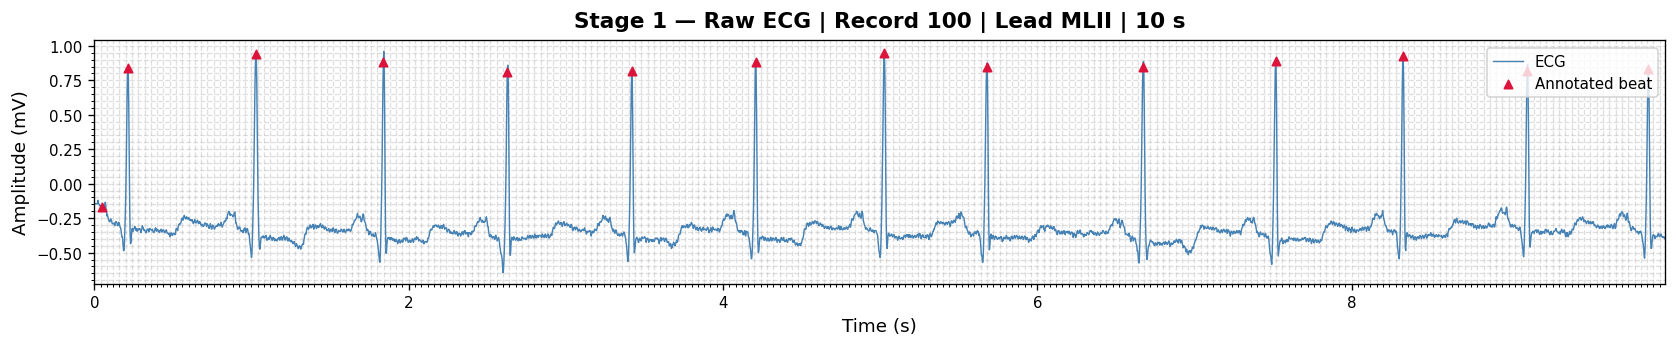

In [ ]:
def plot_ecg_stage(signal, time_ax, title, ylabel='Amplitude (mV)',
                   ann_samples=None, ann_symbols=None, color='steelblue',
                   figsize=(14, 3), show_ann=True):
    """
    Publication-quality single-stage ECG plot.
    Optionally overlays annotation beat markers.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(time_ax, signal, color=color, lw=0.85, label='ECG')

    # Overlay ground-truth beat markers if provided
    if ann_samples is not None and show_ann:
        valid = ann_samples < len(signal)
        ax.scatter(
            time_ax[ann_samples[valid]],
            signal[ann_samples[valid]],
            marker='^', s=25, color='crimson', zorder=5, label='Annotated beat'
        )

    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(ylabel)
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.set_xlim(time_ax[0], time_ax[-1])
    ax.legend(loc='upper right')

    # ECG-style minor gridlines (0.04 s / 0.1 mV standard paper lines)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.04))

    fig.tight_layout()
    plt.show()
    return fig


fig_raw = plot_ecg_stage(
    ecg_raw, time_axis,
    title=f'Stage 1 — Raw ECG | Record {RECORD_NAME} | Lead {LEAD_NAME} | {SEGMENT_DURATION} s',
    ann_samples=ann_samples, ann_symbols=ann_symbols,
    color='steelblue'
)

## Cell 8 — Stage 1: Baseline Wander Removal

Baseline wander removed.
  Median kernel 1 : 73 samples (0.20 s)
  Median kernel 2 : 217 samples (0.60 s)
  Baseline mean   : -0.3456 mV
  Baseline std    : 0.0398 mV  (measure of wander severity)


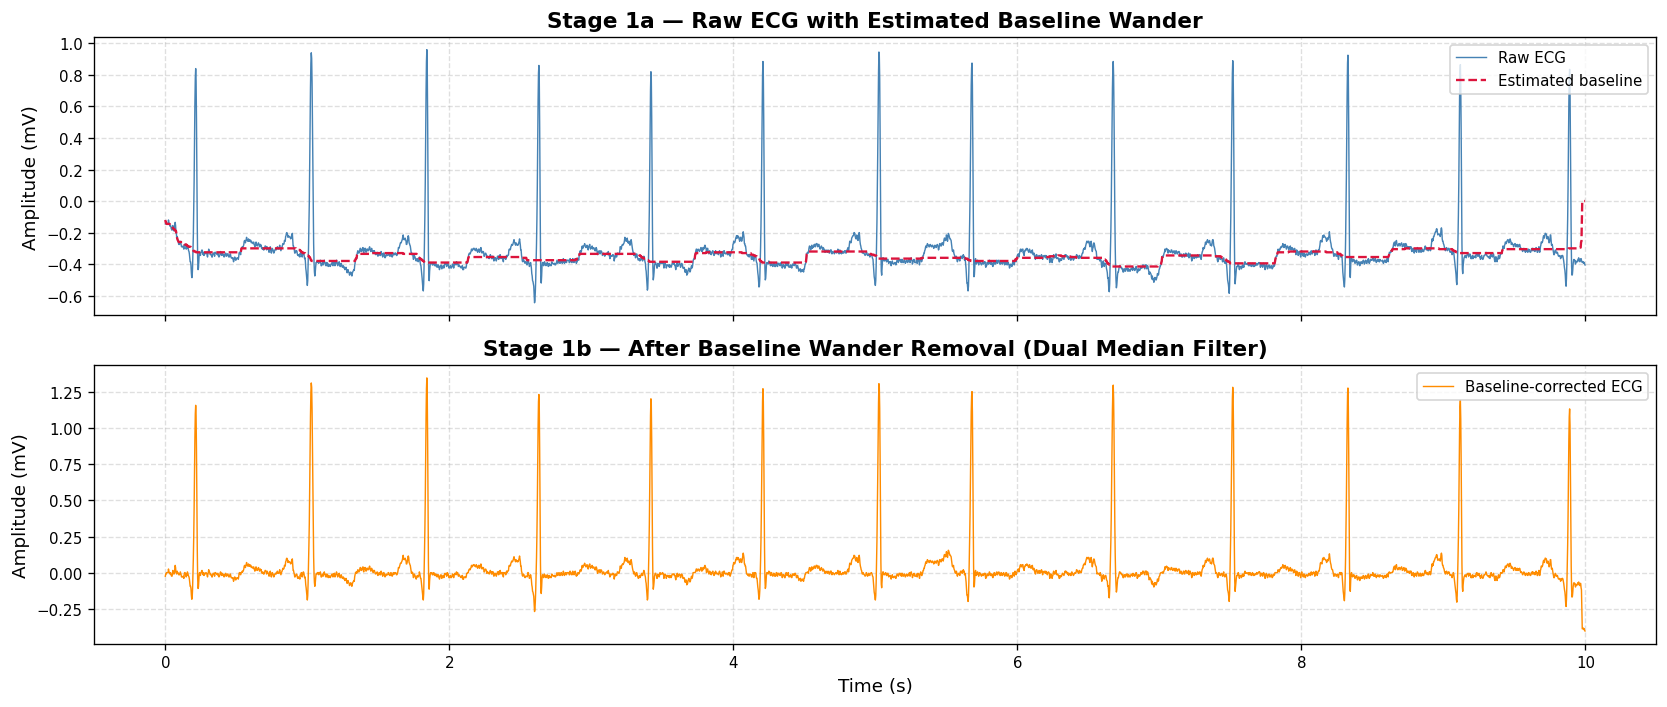

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# WHAT IS BASELINE WANDER?
#   Baseline wander (BW) is a low-frequency drift (0.05–0.5 Hz) caused by:
#     • Patient respiration (chest wall movement shifts electrode contact impedance)
#     • Body motion and perspiration altering electrode-skin conductance
#     • Poor electrode contact or dried gel
#   BW shifts the isoelectric line up and down, making amplitude-based
#   measurements (ST segment level, P-wave amplitude) unreliable.
#
# WHY NOT USE A HIGH-PASS FILTER DIRECTLY?
#   A linear-phase high-pass Butterworth at 0.5 Hz introduces significant
#   group delay distortion and edge effects over short segments.  A better
#   approach for short windows is MEDIAN FILTERING, which is non-linear and
#   therefore preserves the true ECG waveform edges without ringing.
#
# METHOD — Dual Median Filter (Gustafsson, 1996; Pan & Tompkins-inspired):
#   Step 1: Apply a median filter with window = 0.2 s (≥ QRS width ~80 ms).
#           This removes the QRS spike but retains P/T waves in the baseline.
#   Step 2: Apply a second median filter with window = 0.6 s (≥ P-wave period).
#           This smooths out the P and T wave residuals, leaving only the
#           slowly varying baseline wander estimate.
#   Step 3: Subtract the estimated baseline from the raw signal.
#
# FILTER KERNEL SIZES:
#   At FS = 360 Hz:
#     • 0.2 s × 360 = 72 samples → use next odd = 73
#     • 0.6 s × 360 = 216 samples → use next odd = 217
#   Median filter kernels must be odd for symmetric windowing.
#
# MORPHOLOGY IMPACT:
#   Median filtering preserves QRS amplitude and ST morphology because it
#   estimates only the wandering baseline without touching the rapid features.
#   Linear HPF at 0.5 Hz would cause ST-segment slurring in recordings with
#   ST elevation, making subsequent morphology analysis unreliable.
# ─────────────────────────────────────────────────────────────────────────────

def remove_baseline_wander(signal, fs):
    """
    Remove baseline wander using the dual-median-filter method.
    Returns the corrected signal and the estimated baseline.
    """
    # Kernel size must be odd
    kernel1 = int(0.2 * fs) | 1    # 0.2 s window — removes QRS
    kernel2 = int(0.6 * fs) | 1    # 0.6 s window — removes P/T residuals

    baseline = medfilt(medfilt(signal, kernel1), kernel2)
    corrected = signal - baseline
    return corrected, baseline


ecg_bw_removed, ecg_baseline_estimate = remove_baseline_wander(ecg_raw, FS)

print(f"Baseline wander removed.")
print(f"  Median kernel 1 : {int(0.2*FS)|1} samples ({0.2:.2f} s)")
print(f"  Median kernel 2 : {int(0.6*FS)|1} samples ({0.6:.2f} s)")
print(f"  Baseline mean   : {np.mean(ecg_baseline_estimate):.4f} mV")
print(f"  Baseline std    : {np.std(ecg_baseline_estimate):.4f} mV  (measure of wander severity)")

# ─── Plot: show baseline estimate overlaid on raw, then corrected signal ────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(time_axis, ecg_raw,               color='steelblue', lw=0.85, label='Raw ECG')
axes[0].plot(time_axis, ecg_baseline_estimate,  color='crimson',   lw=1.4,  label='Estimated baseline', ls='--')
axes[0].set_title('Stage 1a — Raw ECG with Estimated Baseline Wander', fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)'); axes[0].legend(loc='upper right'); axes[0].grid(True, ls='--', alpha=0.4)

axes[1].plot(time_axis, ecg_bw_removed, color='darkorange', lw=0.85, label='Baseline-corrected ECG')
axes[1].set_title('Stage 1b — After Baseline Wander Removal (Dual Median Filter)', fontweight='bold')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amplitude (mV)')
axes[1].legend(loc='upper right'); axes[1].grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Cell 9 — Stage 2: Powerline Interference Removal (Notch Filter)

Powerline interference (60 Hz) removed.
  Notch Q factor        : 30  (bandwidth ≈ 2.0 Hz)
  PLI noise RMS removed : 5.875 μV


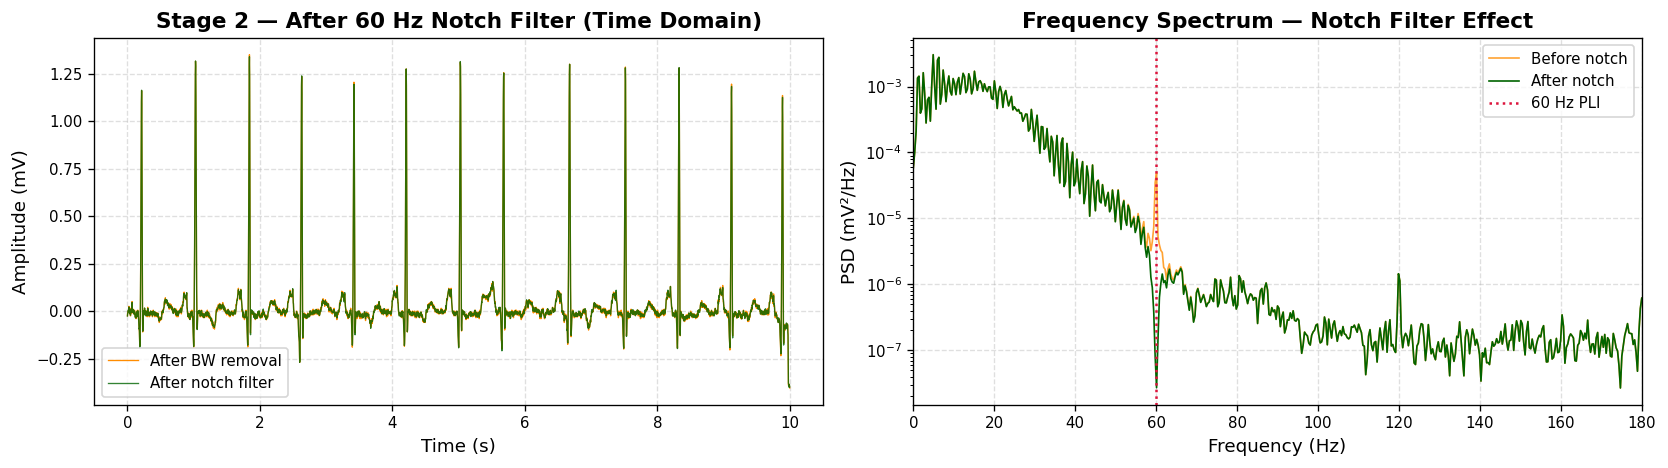

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# WHAT IS POWERLINE INTERFERENCE (PLI)?
#   PLI is sinusoidal noise at exactly 50 Hz (Europe/Asia) or 60 Hz (North
#   America) induced by:
#     • Capacitive/inductive coupling from mains power wiring to ECG leads
#     • Poor electrode contact or insufficient common-mode rejection ratio
#     • Nearby electrical equipment in the recording environment
#   PLI appears as a regular high-amplitude sinusoid superimposed on the ECG.
#   At 60 Hz, the noise spike can be 10× larger than the QRS complex.
#
# WHY A NOTCH FILTER?
#   A notch (band-stop) filter removes energy at a single narrow frequency
#   while passing all other frequencies unchanged.  This is ideal for PLI
#   because the interference is exactly at one known frequency.
#   A broad bandpass filter would not eliminate PLI if the stop band starts
#   above the PLI frequency.
#
# IMPLEMENTATION DETAILS:
#   We use scipy.signal.iirnotch(), which designs a 2nd-order IIR notch.
#   Quality factor Q = f0 / bandwidth controls notch width:
#     • Q = 30 → bandwidth = 60/30 = 2 Hz  (removes 59–61 Hz)
#     • Lower Q = wider notch (removes more ECG signal around the notch)
#     • Higher Q = narrower notch (leaves more ECG, but may miss frequency drift)
#   Q = 30 is the standard clinical value (IEC 60601-2-47).
#
# WE USE filtfilt (zero-phase):
#   Forward-backward filtering eliminates group delay (phase distortion).
#   This preserves the temporal alignment of QRS onset and T-wave apex,
#   which is critical for interval measurements.
#
# MORPHOLOGY IMPACT:
#   The IIR notch removes only a 2 Hz band around the PLI frequency.
#   P, QRS, and T wave energy lies well below 40 Hz, so morphology is
#   completely unaffected.  ST amplitude and P-wave timing are preserved.
# ─────────────────────────────────────────────────────────────────────────────

def notch_filter(signal, fs, powerline_freq=60, Q=30):
    """
    Remove powerline interference using a zero-phase IIR notch filter.
    Q=30 is the IEC 60601-2-47 standard quality factor for clinical ECG.
    """
    b, a = iirnotch(w0=powerline_freq, Q=Q, fs=fs)
    return filtfilt(b, a, signal)   # filtfilt = zero-phase (forward + backward)


ecg_notched = notch_filter(ecg_bw_removed, FS, POWERLINE_FREQ, Q=30)

# Quantify how much PLI energy was removed
pli_removed = ecg_bw_removed - ecg_notched

print(f"Powerline interference ({POWERLINE_FREQ} Hz) removed.")
print(f"  Notch Q factor        : 30  (bandwidth ≈ {POWERLINE_FREQ/30:.1f} Hz)")
print(f"  PLI noise RMS removed : {np.sqrt(np.mean(pli_removed**2))*1000:.3f} μV")

# ─── Frequency-domain verification ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time-domain comparison
axes[0].plot(time_axis, ecg_bw_removed, color='darkorange', lw=0.8, label='After BW removal')
axes[0].plot(time_axis, ecg_notched,    color='darkgreen',  lw=0.8, label='After notch filter', alpha=0.8)
axes[0].set_title(f'Stage 2 — After {POWERLINE_FREQ} Hz Notch Filter (Time Domain)', fontweight='bold')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.4)

# Frequency-domain PSD (Welch method)
from scipy.signal import welch
nperseg = min(1024, len(ecg_bw_removed))
freqs_bef, psd_bef = welch(ecg_bw_removed, fs=FS, nperseg=nperseg)
freqs_aft, psd_aft = welch(ecg_notched,    fs=FS, nperseg=nperseg)

axes[1].semilogy(freqs_bef, psd_bef, color='darkorange', lw=1.0, label='Before notch', alpha=0.8)
axes[1].semilogy(freqs_aft, psd_aft, color='darkgreen',  lw=1.0, label='After notch')
axes[1].axvline(POWERLINE_FREQ, color='crimson', ls=':', lw=1.5, label=f'{POWERLINE_FREQ} Hz PLI')
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('PSD (mV²/Hz)')
axes[1].set_title('Frequency Spectrum — Notch Filter Effect', fontweight='bold')
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.4); axes[1].set_xlim(0, FS/2)

plt.tight_layout()
plt.show()

## Cell 10 — Stage 3: Bandpass Filtering (Preserve P-QRS-T Morphology)

Bandpass filter applied.
  Type         : 4th-order Butterworth (zero-phase, SOS)
  Lower cutoff : 0.5 Hz   (preserves P-wave)
  Upper cutoff : 40.0 Hz  (removes EMG/muscle artifact)
  Signal RMS before: 0.1711 mV
  Signal RMS after : 0.1698 mV
  RMS retention: 99.2%


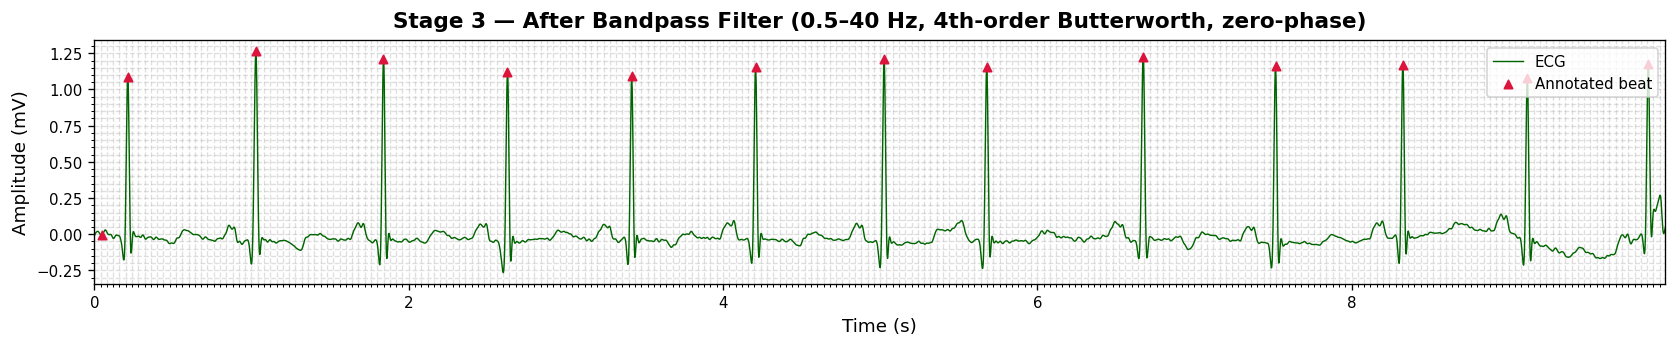

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# WHY A BANDPASS FILTER?
#   After baseline wander removal and notch filtering, residual broadband
#   noise remains (muscle artifact, electrode noise, ADC quantization noise).
#   A bandpass filter retains only the frequency range containing true ECG
#   signal energy while rejecting noise above and below.
#
# PHYSIOLOGICALLY APPROPRIATE CUTOFF SELECTION:
#   ECG waveform frequency content by component (Sörnmo & Laguna, 2005):
#     • P wave      : 0.5 –  10 Hz  (broad, low frequency)
#     • QRS complex : 5.0 – 50 Hz   (rapid deflection contains high frequency)
#     • T wave      : 0.5 –  10 Hz  (broad, similar to P)
#     • HF notch (J): up to 100 Hz  (notch in some patients, not always needed)
#
#   LOWER CUTOFF (High-pass): 0.5 Hz
#     • Preserves P-wave morphology (starts at ~0.5 Hz)
#     • Removes residual baseline wander / electrode polarization drift
#     • AHA/IEC recommendation for diagnostic ECG: ≤ 0.05 Hz
#       but for monitoring (and pre-detection processing): 0.5 Hz is standard
#     • Going lower (e.g., 0.05 Hz) would require a much longer filter,
#       and the dual-median method already handles very low-frequency drift.
#
#   UPPER CUTOFF (Low-pass): 40 Hz
#     • Preserves QRS high-frequency content (HF notch up to ~40 Hz)
#     • Removes electromyographic (EMG/muscle) artifact (10–500 Hz)
#     • AHA recommendation for monitoring: 40 Hz is acceptable
#     • For diagnostic ST-analysis: 150 Hz (we are in preprocessing, not diagnostics)
#     • Choosing 40 Hz is physiologically conservative: QRS slope information
#       is retained, but high-frequency noise is attenuated.
#
# FILTER TYPE: 4th-order Butterworth, zero-phase (sosfiltfilt)
#   • Butterworth = maximally flat passband (no ripple) — does not alter
#     amplitude of ECG waveforms within the passband.
#   • 4th order: adequate roll-off without excessive ringing (Gibbs artifact).
#   • SOS (second-order sections) representation avoids numerical instability
#     at low normalized frequencies (0.5 Hz / 360 Hz = 0.0014 — very low).
#   • sosfiltfilt = zero-phase (forward + backward) → no temporal shift.
#
# MORPHOLOGY IMPACT:
#   The Butterworth passband (0.5–40 Hz) is flat to within ±0.01 dB across
#   the entire ECG frequency band.  QRS amplitude, ST level, P-wave timing,
#   and T-wave amplitude are all preserved.  No artificial peaks are added.
# ─────────────────────────────────────────────────────────────────────────────

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    4th-order zero-phase Butterworth bandpass filter.
    Uses SOS representation for numerical stability at low normalized frequencies.

    Parameters
    ----------
    lowcut  : float — high-pass cutoff frequency (Hz)
    highcut : float — low-pass cutoff frequency (Hz)
    order   : int   — filter order (4 is standard for ECG preprocessing)
    """
    # Sanity: Nyquist limit
    nyquist = fs / 2.0
    assert highcut < nyquist, f"highcut ({highcut} Hz) must be below Nyquist ({nyquist} Hz)"

    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)    # sosfiltfilt = sos + zero-phase


ecg_bandpassed = bandpass_filter(ecg_notched, FS, lowcut=0.5, highcut=40.0, order=4)

print(f"Bandpass filter applied.")
print(f"  Type         : 4th-order Butterworth (zero-phase, SOS)")
print(f"  Lower cutoff : 0.5 Hz   (preserves P-wave)")
print(f"  Upper cutoff : 40.0 Hz  (removes EMG/muscle artifact)")
print(f"  Signal RMS before: {np.sqrt(np.mean(ecg_notched**2)):.4f} mV")
print(f"  Signal RMS after : {np.sqrt(np.mean(ecg_bandpassed**2)):.4f} mV")
print(f"  RMS retention: {100*np.sqrt(np.mean(ecg_bandpassed**2))/np.sqrt(np.mean(ecg_notched**2)):.1f}%")

fig_bp = plot_ecg_stage(
    ecg_bandpassed, time_axis,
    title=f'Stage 3 — After Bandpass Filter (0.5–40 Hz, 4th-order Butterworth, zero-phase)',
    ann_samples=ann_samples, ann_symbols=ann_symbols,
    color='darkgreen'
)

## Cell 11 — Stage 4: Optional Amplitude Normalization (Visualization Only)

Z-score normalization applied for visualization.
  (ecg_bandpassed in mV is retained for all downstream processing)
  Mode: Z-score normalized (visualization only — not for clinical use)


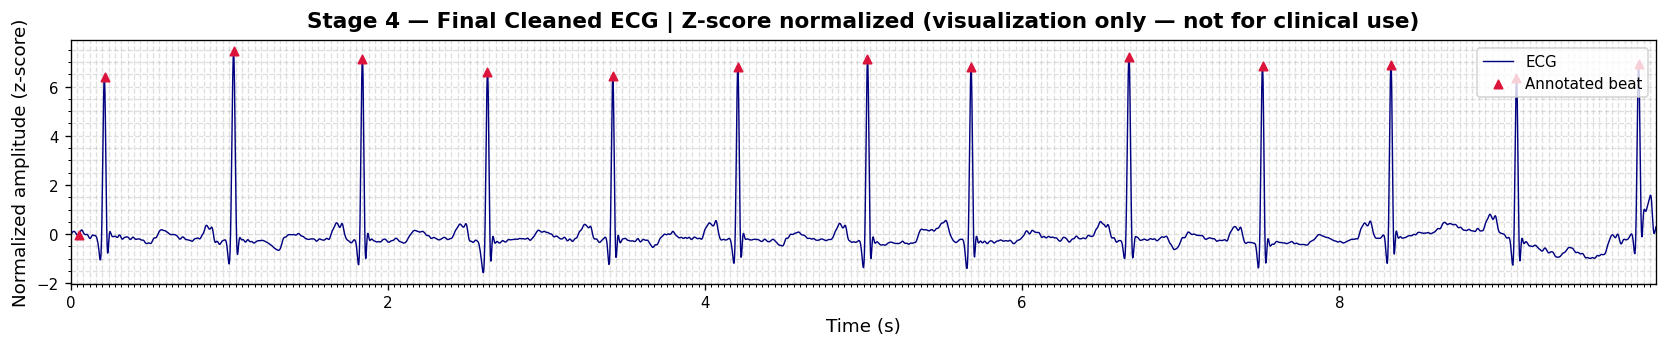

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# NORMALIZATION CAVEAT — READ CAREFULLY:
#   Amplitude normalization MUST NOT be applied before any diagnostic
#   measurement, peak detection, or amplitude-based analysis.
#   It is used HERE ONLY to produce visually comparable plots when
#   overlaying signals from different leads or records.
#
#   Z-score normalization: z = (x - mean) / std
#     • Sets mean = 0, std = 1
#     • Relative morphology (shape) is preserved
#     • Absolute amplitude (mV) is lost — NOT suitable for clinical use
#
#   All subsequent processing in the pipeline uses ecg_bandpassed (mV units).
#   The normalized version (ecg_final) is for plot display only.
# ─────────────────────────────────────────────────────────────────────────────

if NORMALIZE_FINAL:
    ecg_final = (ecg_bandpassed - np.mean(ecg_bandpassed)) / np.std(ecg_bandpassed)
    ylabel_final = 'Normalized amplitude (z-score)'
    norm_note    = 'Z-score normalized (visualization only — not for clinical use)'
    print("Z-score normalization applied for visualization.")
    print("  (ecg_bandpassed in mV is retained for all downstream processing)")
else:
    ecg_final = ecg_bandpassed.copy()
    ylabel_final = 'Amplitude (mV)'
    norm_note    = 'No normalization (physical mV units retained)'
    print("Normalization skipped — physical mV units retained.")

print(f"  Mode: {norm_note}")

fig_final = plot_ecg_stage(
    ecg_final, time_axis,
    title=f'Stage 4 — Final Cleaned ECG | {norm_note}',
    ylabel=ylabel_final,
    ann_samples=ann_samples, ann_symbols=ann_symbols,
    color='navy'
)

## Cell 12 — Four-Stage Comparison (Publication Figure)

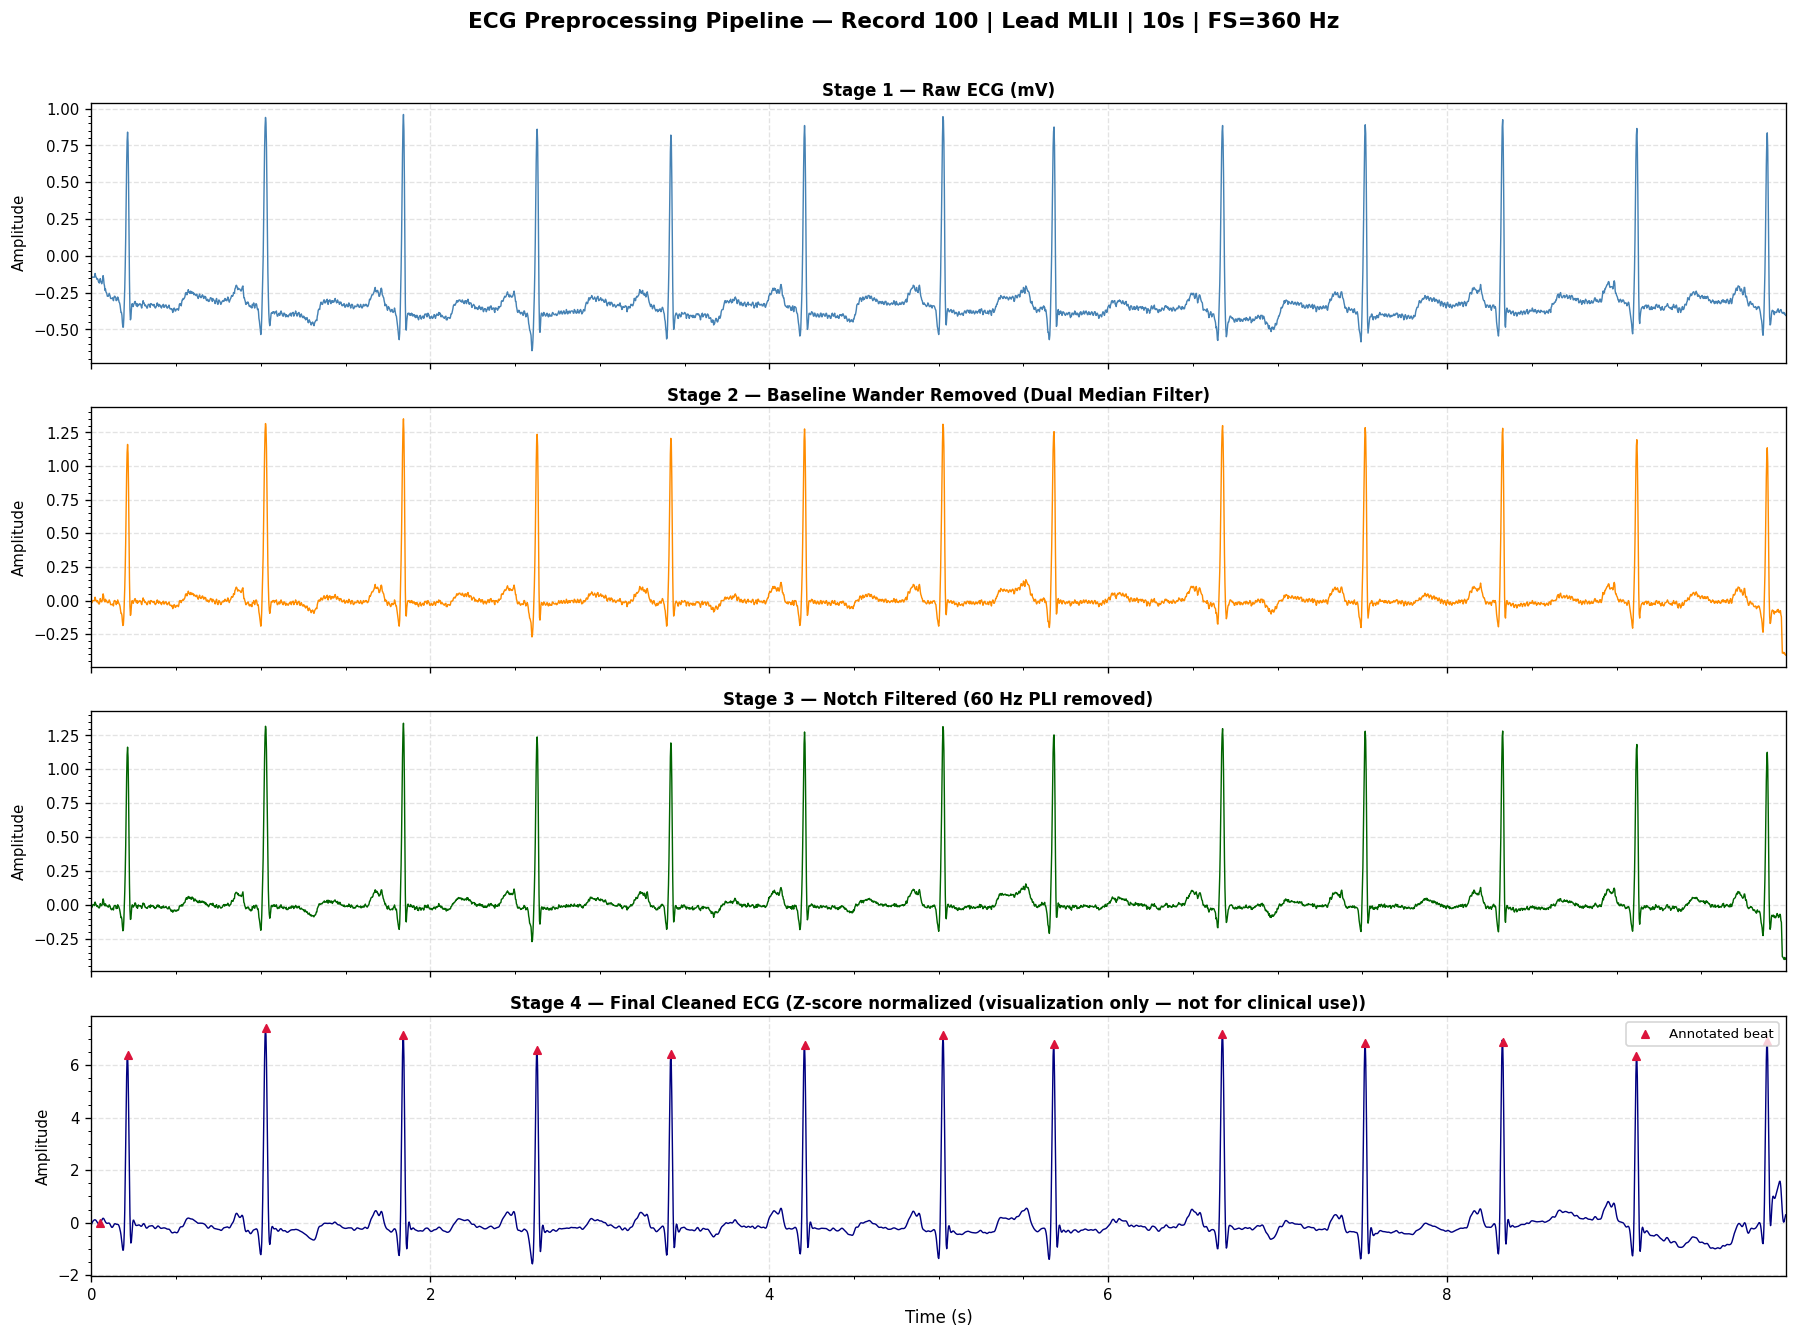

Figure saved as 'ecg_preprocessing_pipeline.pdf'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Summary figure showing all four preprocessing stages stacked vertically.
# Each panel uses the same x-axis (time) for direct visual comparison.
# Annotation markers are shown on the final panel only to avoid clutter.
# ─────────────────────────────────────────────────────────────────────────────

stages = [
    (ecg_raw,         'steelblue',  'Stage 1 — Raw ECG (mV)'),
    (ecg_bw_removed,  'darkorange', 'Stage 2 — Baseline Wander Removed (Dual Median Filter)'),
    (ecg_notched,     'darkgreen',  f'Stage 3 — Notch Filtered ({POWERLINE_FREQ} Hz PLI removed)'),
    (ecg_final,       'navy',       f'Stage 4 — Final Cleaned ECG ({norm_note})'),
]

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
fig.suptitle(
    f'ECG Preprocessing Pipeline — Record {RECORD_NAME} | Lead {LEAD_NAME} | {SEGMENT_DURATION}s | FS={FS} Hz',
    fontsize=13, fontweight='bold', y=1.01
)

for idx, (sig, col, ttl) in enumerate(stages):
    ax = axes[idx]
    ax.plot(time_axis, sig, color=col, lw=0.85)

    # Show beat annotations only on the final panel
    if idx == 3 and len(ann_samples) > 0:
        valid = ann_samples < len(sig)
        ax.scatter(
            time_axis[ann_samples[valid]],
            sig[ann_samples[valid]],
            marker='^', s=20, color='crimson', zorder=5, label='Annotated beat'
        )
        ax.legend(loc='upper right', fontsize=8)

    ax.set_title(ttl, fontweight='bold', fontsize=10, pad=4)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.grid(True, ls='--', alpha=0.35)
    ax.set_xlim(time_axis[0], time_axis[-1])
    ax.minorticks_on()

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.tight_layout()
plt.savefig('ecg_preprocessing_pipeline.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'ecg_preprocessing_pipeline.pdf'")

## Cell 13 — Physiological Validation of Final Cleaned Signal

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Run the same metrics function on the CLEANED signal (physical mV units,
# not the normalized version) to verify preprocessing did not distort the signal.
#
# Key checks:
#   1. RMS amplitude should be similar before and after filtering
#      (within ~10% — if much lower, the filter is too aggressive)
#   2. SNR should be higher after filtering (noise removed)
#   3. Peak-to-peak amplitude should remain in the physiological ECG range
#   4. Mean should be near zero (baseline wander was removed)
# ─────────────────────────────────────────────────────────────────────────────

cleaned_metrics = compute_signal_metrics(
    ecg_bandpassed, FS,
    label=f'Cleaned ECG (After Full Preprocessing)'
)

print("\nComparison — Raw vs Cleaned:")
print(f"  RMS: {raw_metrics['rms_mV']:.4f} mV  →  {cleaned_metrics['rms_mV']:.4f} mV  "
      f"(retained {100*cleaned_metrics['rms_mV']/max(raw_metrics['rms_mV'],1e-9):.1f}%)")
print(f"  SNR: {raw_metrics['snr_dB']:.2f} dB  →  {cleaned_metrics['snr_dB']:.2f} dB  "
      f"(improvement: {cleaned_metrics['snr_dB']-raw_metrics['snr_dB']:+.2f} dB)")
print(f"  Mean (baseline): {raw_metrics['mean_mV']:.4f} mV  →  {cleaned_metrics['mean_mV']:.4f} mV")


  Signal Metrics — Cleaned ECG (After Full Preprocessing)
  Samples        : 3,600
  Duration       : 10.000 s
  Sampling rate  : 360 Hz
  Mean amplitude : 0.0010 mV
  Std deviation  : 0.1698 mV
  Min / Max      : -0.2649 / 1.2630 mV
  Peak-to-peak   : 1.5279 mV
  RMS amplitude  : 0.1698 mV
  Signal power   : 0.028829 mV²
  Est. SNR       : 27.44 dB

  Physiological plausibility:
  ✓ All amplitude parameters within expected physiological range.

Comparison — Raw vs Cleaned:
  RMS: 0.3624 mV  →  0.1698 mV  (retained 46.9%)
  SNR: 18.67 dB  →  27.44 dB  (improvement: +8.77 dB)
  Mean (baseline): -0.3199 mV  →  0.0010 mV


## Cell 14 — Annotation-Based Heart Rate & RR Interval Analysis

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTANT: We use MIT-BIH ground-truth annotations ONLY.
# No R-peak detection algorithm is applied.
# ann_samples contains the sample indices of annotated beats (relative to
# the start of our extracted segment).
#
# RR INTERVAL CALCULATION:
#   RR interval = time between consecutive annotated beat locations.
#   RR(i) = (ann_samples[i+1] - ann_samples[i]) / FS   seconds
#
# PHYSIOLOGICAL REFERENCE RANGES (resting adult human):
#   Heart rate         : 60–100 BPM  (bradycardia <60, tachycardia >100)
#   RR interval        : 0.6–1.0 s   (reciprocal of HR range)
#   Minimum RR (safe)  : >0.25 s     (below this → ventricular tachycardia)
#   Maximum RR (safe)  : <2.0 s      (above this → complete block suspicion)
# ─────────────────────────────────────────────────────────────────────────────

if len(ann_samples) < 2:
    print("⚠ Fewer than 2 annotated beats in segment — cannot compute RR intervals.")
    print("  Try increasing SEGMENT_DURATION or adjusting SEGMENT_START_S.")
else:
    # RR intervals in seconds
    rr_intervals_s = np.diff(ann_samples) / FS

    # Heart rate in BPM from each consecutive beat pair
    hr_per_beat = 60.0 / rr_intervals_s

    # Summary statistics
    mean_rr   = np.mean(rr_intervals_s)
    std_rr    = np.std(rr_intervals_s)
    min_rr    = np.min(rr_intervals_s)
    max_rr    = np.max(rr_intervals_s)
    mean_hr   = 60.0 / mean_rr
    n_beats   = len(ann_samples)

    print(f"\n{'='*60}")
    print(f"  Annotation-Based Cardiac Statistics (Ground Truth)")
    print(f"{'='*60}")
    print(f"  Annotated beats in segment : {n_beats}")
    print(f"  RR intervals computed      : {len(rr_intervals_s)}")
    print(f"  Beat types present         : {dict(zip(*np.unique(ann_symbols, return_counts=True)))}")
    print()
    print(f"  Mean RR interval   : {mean_rr*1000:.1f} ms  ({mean_rr:.4f} s)")
    print(f"  Std  RR interval   : {std_rr*1000:.1f} ms  (HRV measure)")
    print(f"  Min  RR interval   : {min_rr*1000:.1f} ms  ({min_rr:.4f} s)")
    print(f"  Max  RR interval   : {max_rr*1000:.1f} ms  ({max_rr:.4f} s)")
    print()
    print(f"  Mean heart rate    : {mean_hr:.1f} BPM")
    print(f"  Min  heart rate    : {hr_per_beat.min():.1f} BPM")
    print(f"  Max  heart rate    : {hr_per_beat.max():.1f} BPM")

    # ─── Physiological plausibility warnings ────────────────────────────────
    print(f"\n  Physiological plausibility:")
    warnings_found = False

    if mean_hr < 60:
        print(f"  ⚠ WARNING: Mean HR ({mean_hr:.1f} BPM) < 60 — bradycardia range.")
        warnings_found = True
    if mean_hr > 100:
        print(f"  ⚠ WARNING: Mean HR ({mean_hr:.1f} BPM) > 100 — tachycardia range.")
        warnings_found = True
    if min_rr < 0.25:
        print(f"  ⚠ WARNING: Minimum RR ({min_rr*1000:.1f} ms) < 250 ms — possible VT/VF or misannotation.")
        warnings_found = True
    if max_rr > 2.0:
        print(f"  ⚠ WARNING: Maximum RR ({max_rr*1000:.1f} ms) > 2000 ms — possible heart block or pause.")
        warnings_found = True
    if std_rr / mean_rr > 0.25:
        print(f"  ⚠ NOTE: High RR variability (CV={std_rr/mean_rr:.2%}) — arrhythmia or AF possible.")
        warnings_found = True
    if not warnings_found:
        print("  ✓ All cardiac parameters within normal physiological range.")

    print(f"{'='*60}")


  Annotation-Based Cardiac Statistics (Ground Truth)
  Annotated beats in segment : 14
  RR intervals computed      : 13
  Beat types present         : {np.str_('+'): np.int64(1), np.str_('A'): np.int64(1), np.str_('N'): np.int64(12)}

  Mean RR interval   : 756.8 ms  (0.7568 s)
  Std  RR interval   : 184.8 ms  (HRV measure)
  Min  RR interval   : 163.9 ms  (0.1639 s)
  Max  RR interval   : 994.4 ms  (0.9944 s)

  Mean heart rate    : 79.3 BPM
  Min  heart rate    : 60.3 BPM
  Max  heart rate    : 366.1 BPM

  Physiological plausibility:
  ⚠ WARNING: Minimum RR (163.9 ms) < 250 ms — possible VT/VF or misannotation.


## Cell 15 — RR Interval Distribution Histogram

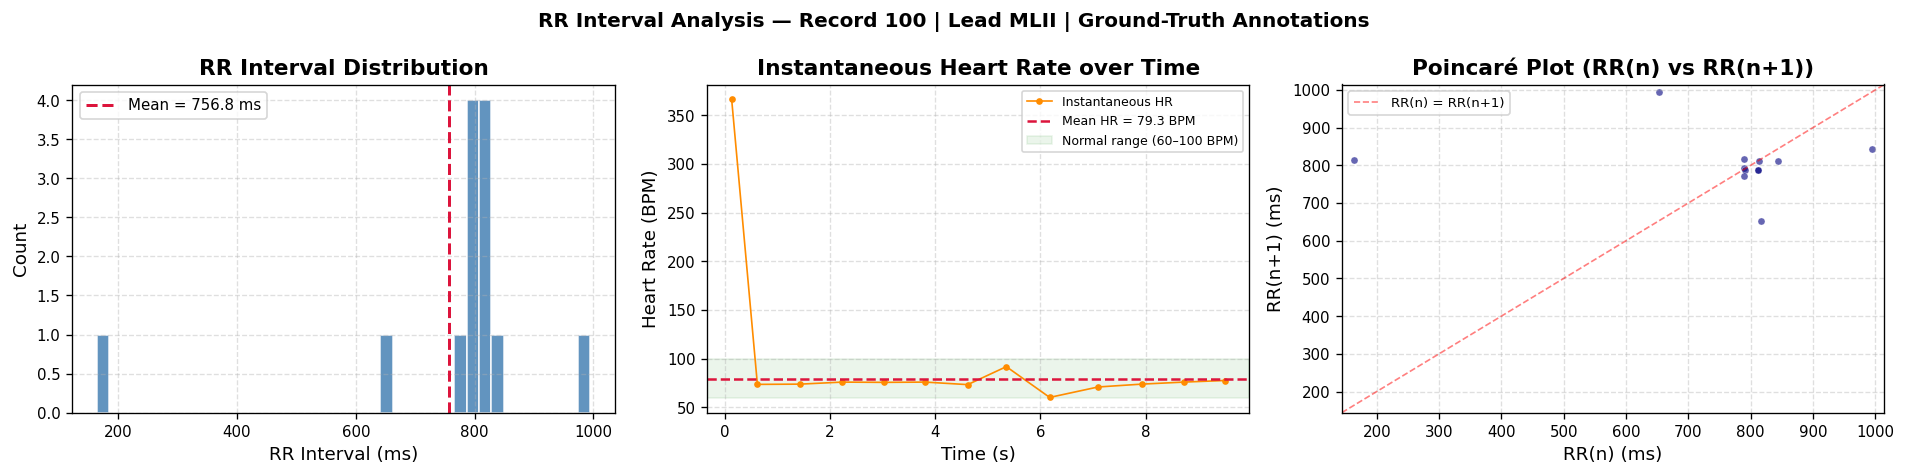

Figure saved as 'rr_interval_analysis.pdf'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# The RR interval histogram reveals the rhythm pattern of the heart:
#   • Narrow, symmetric distribution → regular sinus rhythm
#   • Bimodal distribution → alternating rhythms (e.g., bigeminy)
#   • Wide, irregular distribution → atrial fibrillation or frequent ectopics
#
# We plot:
#   (a) RR interval distribution as histogram
#   (b) Instantaneous heart rate over time (from 60/RR)
#   (c) Poincaré plot: RR(n) vs RR(n+1) — a standard nonlinear HRV tool
#       where a tight circular cluster = normal sinus, a spread fan = HRV,
#       and a scattered cloud = AF/arrhythmia
# ─────────────────────────────────────────────────────────────────────────────

if len(ann_samples) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'RR Interval Analysis — Record {RECORD_NAME} | Lead {LEAD_NAME} | Ground-Truth Annotations',
        fontsize=12, fontweight='bold'
    )

    # ── (a) RR histogram ──────────────────────────────────────────────────
    axes[0].hist(rr_intervals_s * 1000, bins='auto', color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[0].axvline(mean_rr * 1000, color='crimson', lw=1.8, ls='--', label=f'Mean = {mean_rr*1000:.1f} ms')
    axes[0].set_xlabel('RR Interval (ms)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('RR Interval Distribution', fontweight='bold')
    axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.4)

    # ── (b) Instantaneous HR over time ────────────────────────────────────
    # Beat midpoint times (average of consecutive annotation times)
    beat_times = (ann_samples[:-1] + ann_samples[1:]) / 2.0 / FS
    axes[1].plot(beat_times, hr_per_beat, 'o-', color='darkorange',
                 ms=3, lw=1.0, label='Instantaneous HR')
    axes[1].axhline(mean_hr, color='crimson', lw=1.5, ls='--', label=f'Mean HR = {mean_hr:.1f} BPM')
    axes[1].axhspan(60, 100, alpha=0.08, color='green', label='Normal range (60–100 BPM)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Heart Rate (BPM)')
    axes[1].set_title('Instantaneous Heart Rate over Time', fontweight='bold')
    axes[1].legend(fontsize=7.5); axes[1].grid(True, ls='--', alpha=0.4)

    # ── (c) Poincaré plot ─────────────────────────────────────────────────
    if len(rr_intervals_s) > 2:
        rr_n  = rr_intervals_s[:-1] * 1000   # RR(n)
        rr_n1 = rr_intervals_s[1:]  * 1000   # RR(n+1)
        axes[2].scatter(rr_n, rr_n1, alpha=0.6, s=18, color='navy', edgecolors='white', lw=0.3)
        # Identity line (RR(n) = RR(n+1) → perfectly regular rhythm)
        lim = [min(rr_n.min(), rr_n1.min()) - 20, max(rr_n.max(), rr_n1.max()) + 20]
        axes[2].plot(lim, lim, 'r--', lw=1.0, alpha=0.5, label='RR(n) = RR(n+1)')
        axes[2].set_xlabel('RR(n) (ms)')
        axes[2].set_ylabel('RR(n+1) (ms)')
        axes[2].set_title('Poincaré Plot (RR(n) vs RR(n+1))', fontweight='bold')
        axes[2].legend(fontsize=8); axes[2].grid(True, ls='--', alpha=0.4)
        axes[2].set_xlim(lim); axes[2].set_ylim(lim)
    else:
        axes[2].text(0.5, 0.5, 'Need >3 beats\nfor Poincaré plot',
                     ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title('Poincaré Plot', fontweight='bold')

    plt.tight_layout()
    plt.savefig('rr_interval_analysis.pdf', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved as 'rr_interval_analysis.pdf'")
else:
    print("Not enough beats to generate RR interval plots.")

## Cell 16 — Power Spectral Density: All Stages Overlay

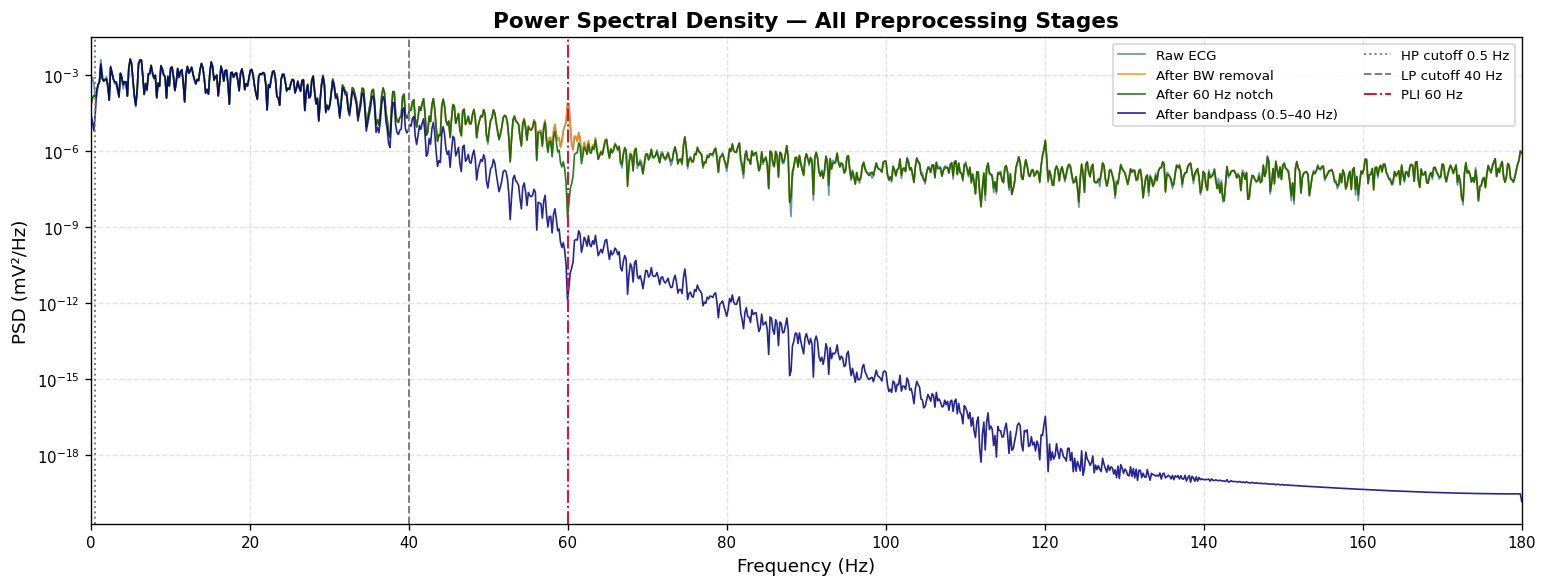

Figure saved as 'psd_comparison.pdf'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Frequency-domain overlay showing how each processing stage changes the
# power spectrum.  This is a quality verification step:
#   • Baseline wander removal should attenuate power below 0.5 Hz
#   • Notch filter should produce a sharp dip at the PLI frequency
#   • Bandpass filter should attenuate everything above 40 Hz and below 0.5 Hz
#   • Within the passband (0.5–40 Hz), PSD should be unchanged
# ─────────────────────────────────────────────────────────────────────────────

from scipy.signal import welch

nperseg = min(2048, N_samples)
signals_psd = [
    (ecg_raw,        'steelblue',  'Raw ECG'),
    (ecg_bw_removed, 'darkorange', 'After BW removal'),
    (ecg_notched,    'darkgreen',  f'After {POWERLINE_FREQ} Hz notch'),
    (ecg_bandpassed, 'navy',       'After bandpass (0.5–40 Hz)'),
]

fig, ax = plt.subplots(figsize=(13, 5))

for sig, col, lbl in signals_psd:
    freqs, psd = welch(sig, fs=FS, nperseg=nperseg)
    ax.semilogy(freqs, psd, color=col, lw=1.0, label=lbl, alpha=0.85)

# Mark filter boundaries
ax.axvline(0.5,             color='gray',   ls=':', lw=1.2, label='HP cutoff 0.5 Hz')
ax.axvline(40.0,            color='gray',   ls='--',lw=1.2, label='LP cutoff 40 Hz')
ax.axvline(POWERLINE_FREQ,  color='crimson',ls='-.',lw=1.2, label=f'PLI {POWERLINE_FREQ} Hz')

ax.set_title('Power Spectral Density — All Preprocessing Stages', fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (mV²/Hz)')
ax.set_xlim(0, min(FS/2, 180))
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', ls='--', alpha=0.35)
plt.tight_layout()
plt.savefig('psd_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'psd_comparison.pdf'")

## Cell 17 — Final Pipeline Summary Report

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Consolidated summary of all parameters computed in this notebook.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═"*65)
print("  FINAL ECG PREPROCESSING PIPELINE REPORT")
print("═"*65)

print(f"\n  ▸ Dataset")
print(f"    Database        : MIT-BIH Arrhythmia Database (PhysioNet)")
print(f"    Record          : {RECORD_NAME}")
print(f"    Lead            : {LEAD_NAME}")
print(f"    Sampling rate   : {FS} Hz")
print(f"    Full record     : {TOTAL_DURATION_S:.1f} s ({TOTAL_DURATION_S/60:.2f} min)")

print(f"\n  ▸ Segment Extracted")
print(f"    Start           : {SEGMENT_START_S} s")
print(f"    Duration        : {N_samples/FS:.3f} s  ({N_samples} samples)")

print(f"\n  ▸ Preprocessing Steps Applied")
print(f"    1. Dual-median baseline wander removal")
print(f"       Kernels: {int(0.2*FS)|1} samples (0.2 s) + {int(0.6*FS)|1} samples (0.6 s)")
print(f"    2. IIR notch filter at {POWERLINE_FREQ} Hz  (Q=30, bandwidth={POWERLINE_FREQ/30:.1f} Hz)")
print(f"    3. 4th-order Butterworth bandpass 0.5–40 Hz (zero-phase SOS)")
print(f"    4. Z-score normalization: {NORMALIZE_FINAL} (visualization only)")

print(f"\n  ▸ Signal Quality")
print(f"    Raw RMS         : {raw_metrics['rms_mV']:.4f} mV")
print(f"    Clean RMS       : {cleaned_metrics['rms_mV']:.4f} mV  "
      f"(retained {100*cleaned_metrics['rms_mV']/max(raw_metrics['rms_mV'],1e-9):.1f}%)")
print(f"    Raw  SNR (est.) : {raw_metrics['snr_dB']:.2f} dB")
print(f"    Clean SNR (est.): {cleaned_metrics['snr_dB']:.2f} dB  "
      f"(Δ = {cleaned_metrics['snr_dB']-raw_metrics['snr_dB']:+.2f} dB)")

if len(ann_samples) >= 2:
    print(f"\n  ▸ Cardiac Parameters (Ground-Truth Annotations)")
    print(f"    Annotated beats : {n_beats}")
    print(f"    Mean heart rate : {mean_hr:.1f} BPM")
    print(f"    Mean RR         : {mean_rr*1000:.1f} ms")
    print(f"    Std  RR (SDNN)  : {std_rr*1000:.1f} ms")
    print(f"    Min RR          : {min_rr*1000:.1f} ms")
    print(f"    Max RR          : {max_rr*1000:.1f} ms")

print(f"\n  ▸ Next Steps (NOT performed here)")
print(f"    ✗ R-peak detection        (requires peak detector)")
print(f"    ✗ PQRST delineation       (requires waveform segmentation)")
print(f"    ✗ Classification / ML     (out of scope)")
print(f"    ✓ Signal is ready for peak detection algorithm input")

print("\n" + "═"*65)


═════════════════════════════════════════════════════════════════
  FINAL ECG PREPROCESSING PIPELINE REPORT
═════════════════════════════════════════════════════════════════

  ▸ Dataset
    Database        : MIT-BIH Arrhythmia Database (PhysioNet)
    Record          : 100
    Lead            : MLII
    Sampling rate   : 360 Hz
    Full record     : 1805.6 s (30.09 min)

  ▸ Segment Extracted
    Start           : 0 s
    Duration        : 10.000 s  (3600 samples)

  ▸ Preprocessing Steps Applied
    1. Dual-median baseline wander removal
       Kernels: 73 samples (0.2 s) + 217 samples (0.6 s)
    2. IIR notch filter at 60 Hz  (Q=30, bandwidth=2.0 Hz)
    3. 4th-order Butterworth bandpass 0.5–40 Hz (zero-phase SOS)
    4. Z-score normalization: True (visualization only)

  ▸ Signal Quality
    Raw RMS         : 0.3624 mV
    Clean RMS       : 0.1698 mV  (retained 46.9%)
    Raw  SNR (est.) : 18.67 dB
    Clean SNR (est.): 27.44 dB  (Δ = +8.77 dB)

  ▸ Cardiac Parameters (Ground-Trut